Aluno: Thiago Yukio Horita Pacheco

Universidade do Vale do Itajaí

Escola Politécnica

Processamento de Imagens

Imagens selecionadas estão disponíveis para download no repositório do trabalho:
https://github.com/thiagoyukiop/Processamento_de_Imagens/tree/main/trab2_M1

Importando pacotes

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Primeiro ciclo


In [ ]:
img1 = cv2.imread("/content/ISIC_0000398.jpg", 1)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread("/content/ISIC_0010208.jpg", 1)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.imread("/content/ISIC_0010313.jpg", 1)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.imread("/content/ISIC_0010737.jpg", 1)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)
imgs = [img1, img2, img3, img4]

In [ ]:
def show_grid(imgs, titles=None, title=None, cmap='gray', figsize=(12, 3), nrows = 1, ncols = 4):
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)

    if titles is None:
        titles = [f'Imagem {i}' for i in range(1, len(imgs) + 1)]

    for ax, img, t in zip(axs.flat, imgs, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(t)

    for ax in axs.flat:
        ax.axis('off')

    if title is not None:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.93] if title else None)
    plt.show()

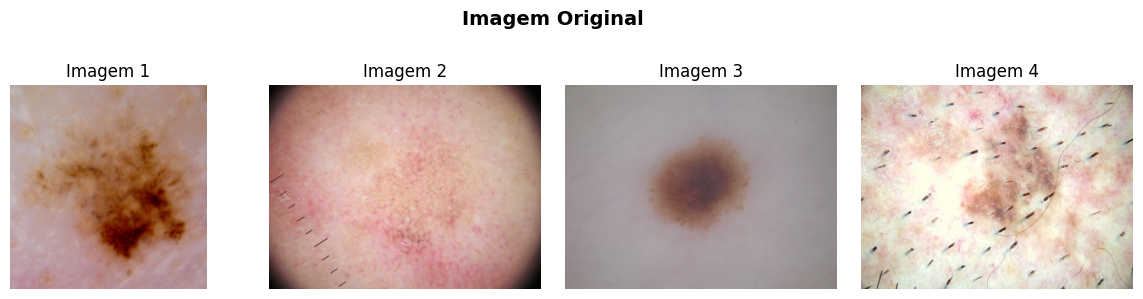

In [ ]:
show_grid(imgs, title="Imagem Original")

Convertendo imagens grayscale (acho que posteriormente pode remover)

In [ ]:
B, G, R = cv2.split(img1)
img1_grayscale_basic = (B+G+R)/3

img1_grayscale_basic = np.array(img1_grayscale_basic, dtype=np.uint8)

In [ ]:
B, G, R = cv2.split(img2)
img2_grayscale_basic = (B+G+R)/3

img2_grayscale_basic = np.array(img2_grayscale_basic, dtype=np.uint8)

In [ ]:
B, G, R = cv2.split(img3)
img3_grayscale_basic = (B+G+R)/3

img3_grayscale_basic = np.array(img3_grayscale_basic, dtype=np.uint8)

In [ ]:
B, G, R = cv2.split(img4)
img4_grayscale_basic = (B+G+R)/3

img4_grayscale_basic = np.array(img4_grayscale_basic, dtype=np.uint8)

In [ ]:
imgs_gray = [img1_grayscale_basic, img2_grayscale_basic, img3_grayscale_basic, img4_grayscale_basic]

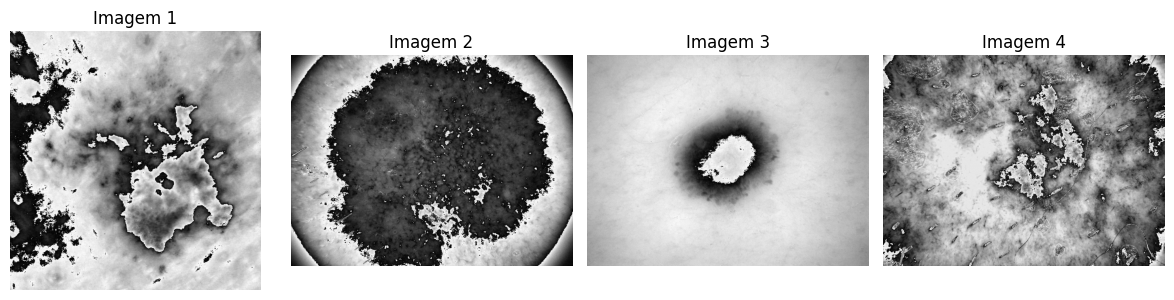

In [ ]:
show_grid(imgs_gray)

Aplicando versão grayscale ponderada

In [ ]:
def pondered_grayscale(img):
  B, G, R = cv2.split(img)
  img_grayscale_pondered = 0.299*B+0.587*G+0.114*R

  img_grayscale_pondered = np.array(img_grayscale_pondered, dtype=np.uint8)

  return img_grayscale_pondered

In [ ]:
imgs_gray_p = [pondered_grayscale(img) for img in imgs]

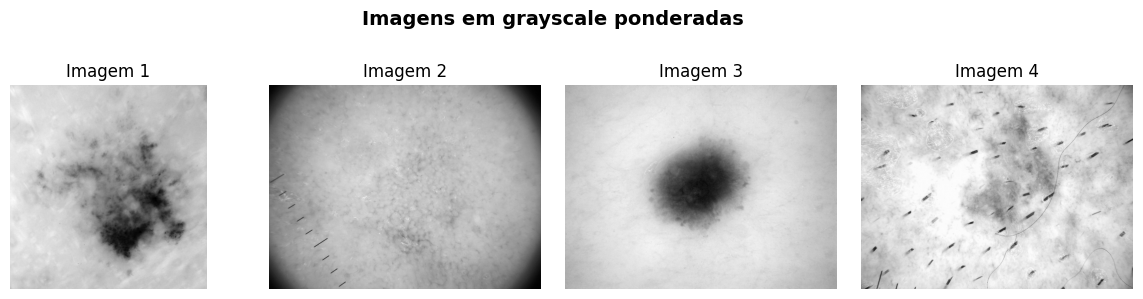

In [ ]:
show_grid(imgs_gray_p, title="Imagens em grayscale ponderadas")

Adicionando ruído as imagens em grayscale ponderadas

In [ ]:
from skimage.util import random_noise

In [ ]:
def adding_noise(img, mode='gaussian', var=0.001):
  img_noise = random_noise(img, mode=mode, var = var, rng=42)

  img_noise = (img_noise * 255).astype(np.uint8)
  return img_noise

In [ ]:
imgs_gray_p_noise_1 = [adding_noise(img, var=0.001) for img in imgs_gray_p]
imgs_gray_p_noise_2 = [adding_noise(img, var=0.01) for img in imgs_gray_p]
imgs_gray_p_noise_3 = [adding_noise(img, var=0.05) for img in imgs_gray_p]

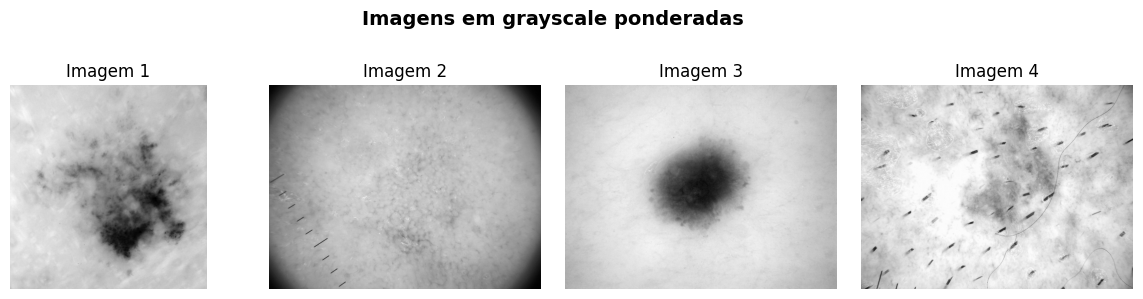

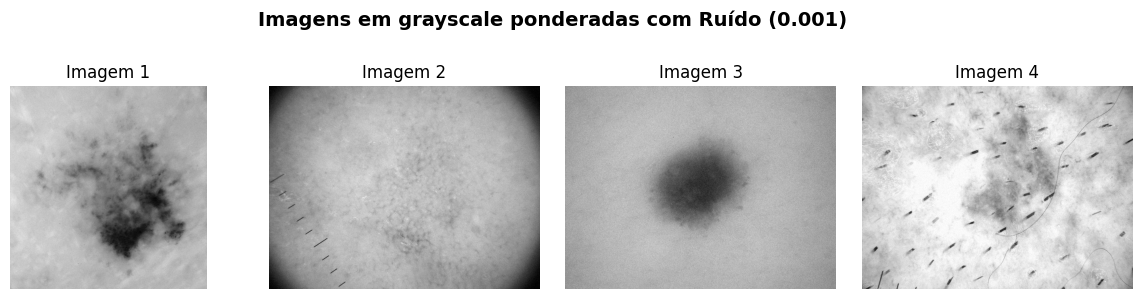

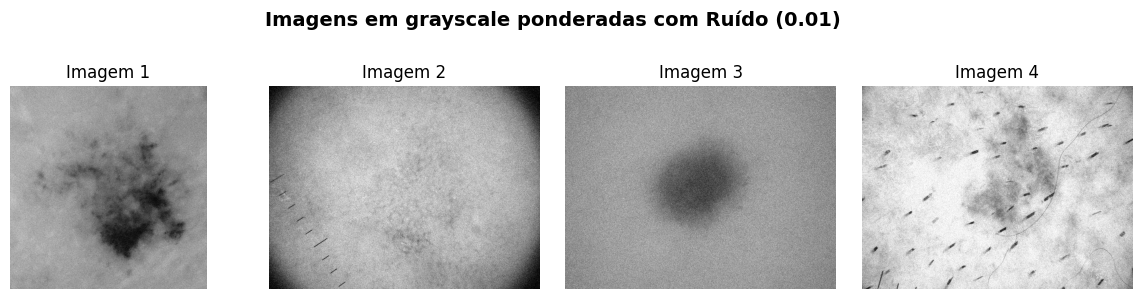

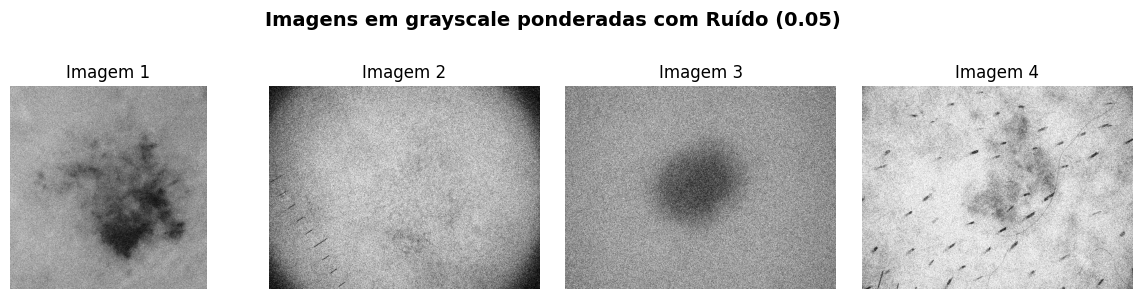

In [ ]:
show_grid(imgs_gray_p, title="Imagens em grayscale ponderadas")
show_grid(imgs_gray_p_noise_1, title="Imagens em grayscale ponderadas com Ruído (0.001)")
show_grid(imgs_gray_p_noise_2, title="Imagens em grayscale ponderadas com Ruído (0.01)")
show_grid(imgs_gray_p_noise_3, title="Imagens em grayscale ponderadas com Ruído (0.05)")

Escolha de uso da imagem com ruído de variabilidade de 0.01 para não ser tão fraco nem ser tão agressivo

In [ ]:
imgs_gray_p_noise = imgs_gray_p_noise_2

Realizar convolução

In [ ]:
def conv2d(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    img_padded = np.pad(img.astype(np.float64), ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    out = np.zeros_like(img, dtype=np.float64)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            out[i, j] = np.sum(img_padded[i:i+kh, j:j+kw] * kernel)
    return out

In [ ]:
import pandas as pd

In [ ]:
from skimage.metrics import structural_similarity as ssim_fn

def mse(imageA, imageB):
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])
    return err

def psnr(imageA, imageB):
    m = mse(imageA, imageB)
    if m == 0:
        return 100
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(m))

Suavizando imagem com ruído

In [ ]:
def mean_kernel(size=3):
    return np.ones((size, size)) / (size * size)

In [ ]:
imgs_filtrados_3 = [np.clip(conv2d(img, mean_kernel(3)), 0, 255).astype(np.uint8) for img in imgs_gray_p_noise]
imgs_filtrados_5 = [np.clip(conv2d(img, mean_kernel(5)), 0, 255).astype(np.uint8) for img in imgs_gray_p_noise]
imgs_filtrados_7 = [np.clip(conv2d(img, mean_kernel(7)), 0, 255).astype(np.uint8) for img in imgs_gray_p_noise]

In [ ]:
imgs_filtrados_9 = [np.clip(conv2d(img, mean_kernel(9)), 0, 255).astype(np.uint8) for img in imgs_gray_p_noise]
imgs_filtrados_11 = [np.clip(conv2d(img, mean_kernel(11)), 0, 255).astype(np.uint8) for img in imgs_gray_p_noise]

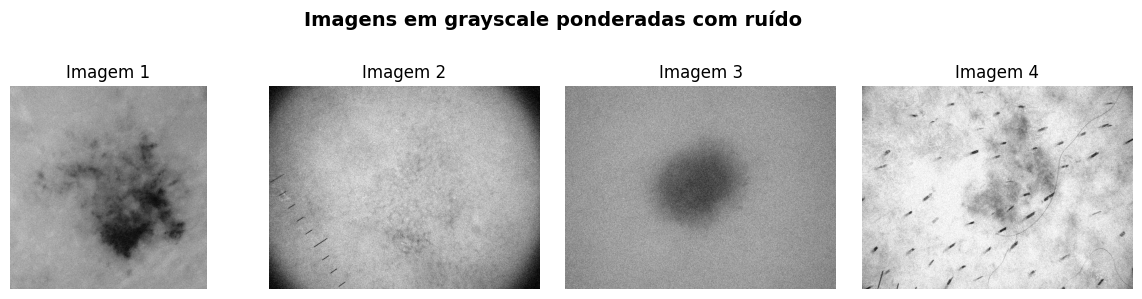

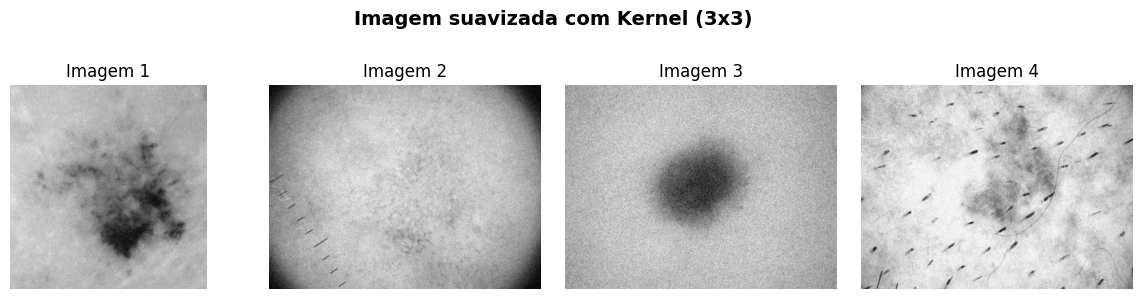

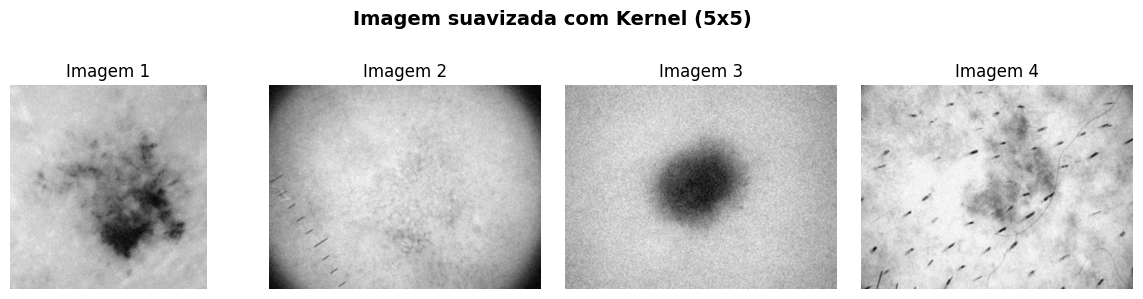

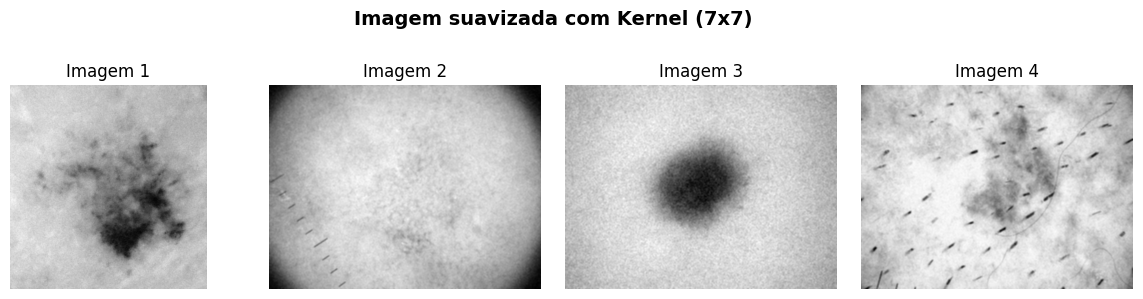

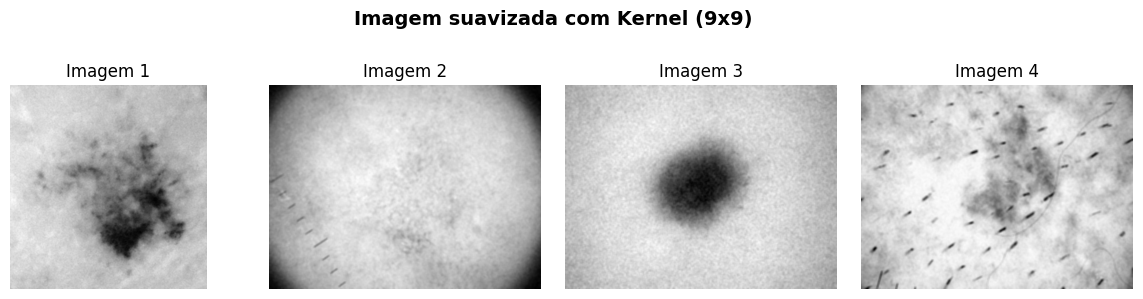

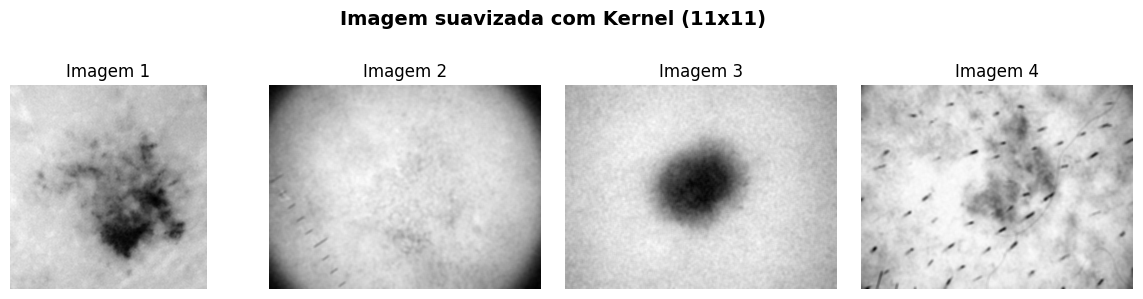

In [ ]:
show_grid(imgs_gray_p_noise, title="Imagens em grayscale ponderadas com ruído")
show_grid(imgs_filtrados_3, title="Imagem suavizada com Kernel (3x3)")
show_grid(imgs_filtrados_5, title="Imagem suavizada com Kernel (5x5)")
show_grid(imgs_filtrados_7, title="Imagem suavizada com Kernel (7x7)")
show_grid(imgs_filtrados_9, title="Imagem suavizada com Kernel (9x9)")
show_grid(imgs_filtrados_11, title="Imagem suavizada com Kernel (11x11)")

In [ ]:
etapas_kernel = {
    'Suavização 3x3': imgs_filtrados_3,
    'Suavização 5x5': imgs_filtrados_5,
    'Suavização 7x7': imgs_filtrados_7,
    'Suavização 9x9': imgs_filtrados_9,
    'Suavização 11x11': imgs_filtrados_11
}

resultados_kernel = []
for nome, imgs_k in etapas_kernel.items():
    for i, (ref, img) in enumerate(zip(imgs_gray_p, imgs_k), start=1):
        resultados_kernel.append({
            'Imagem': i, 'Kernel': nome,
            'PSNR': round(psnr(ref, img), 2),
            'SSIM': round(ssim_fn(ref, img), 4),
        })

df_kernel = pd.DataFrame(resultados_kernel)
df_kernel

,Imagem,Kernel,PSNR,SSIM
0,1,Suavização 3x3,29.45,0.5186
1,2,Suavização 3x3,29.27,0.5354
2,3,Suavização 3x3,29.39,0.4996
3,4,Suavização 3x3,28.37,0.6147
4,1,Suavização 5x5,33.59,0.7690
5,2,Suavização 5x5,32.71,0.7609
6,3,Suavização 5x5,33.56,0.7592
7,4,Suavização 5x5,29.71,0.7618
8,1,Suavização 7x7,35.99,0.8733
9,2,Suavização 7x7,34.05,0.8467


Realizando Histogramas das Imagens

In [ ]:
def show_hist_grid(imgs, titles=None, title=None, figsize=(12, 3), num_pontos=256, intervalo_min_max=[0, 256], nrows=1, ncols=4):
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)

    if titles is None:
        titles = [f'Histograma - Imagem {i}' for i in range(1, len(imgs) + 1)]

    for ax, img, t in zip(axs.flat, imgs, titles):
        point_count, point_edges = np.histogram(img, num_pontos, intervalo_min_max)
        point_start = point_edges[:-1]
        ax.bar(point_start, point_count, width=1)
        ax.set_title(t)

    if title is not None:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

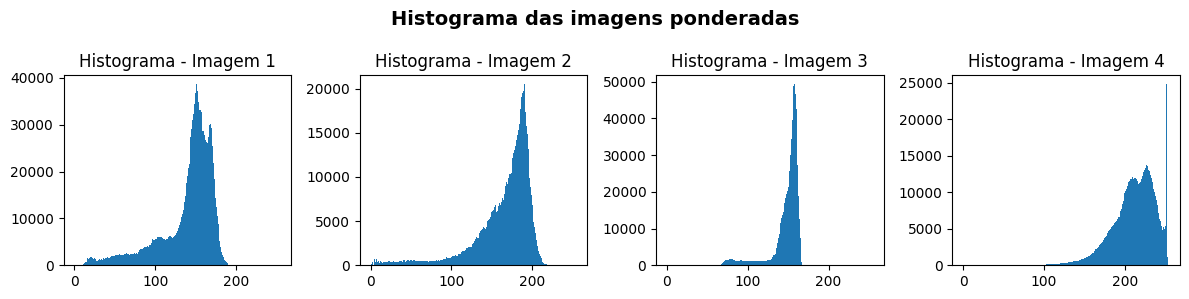

In [ ]:
show_hist_grid(imgs_gray_p, title="Histograma das imagens ponderadas")

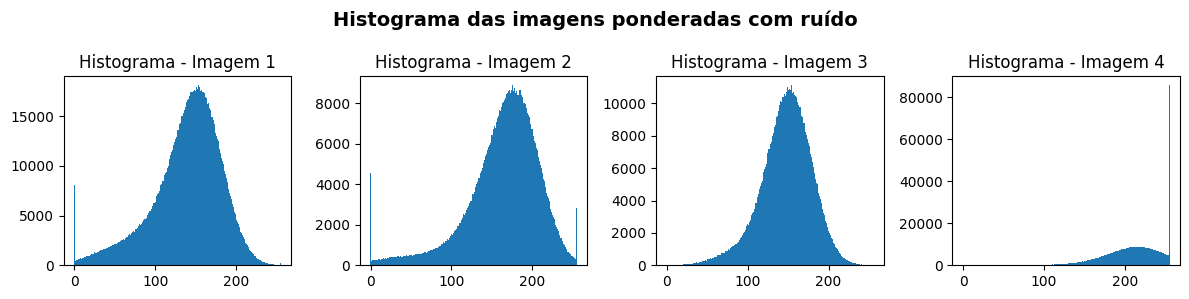

In [ ]:
show_hist_grid(imgs_gray_p_noise, title="Histograma das imagens ponderadas com ruído")

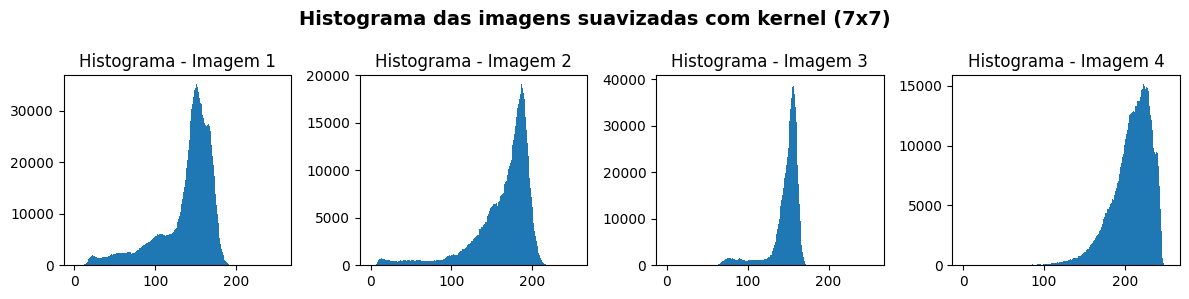

In [ ]:
show_hist_grid(imgs_filtrados_7, title="Histograma das imagens suavizadas com kernel (7x7)")

Operação Pontual sobre imagem filtrada

In [ ]:
def gamma_correction(img, gamma=0.5, c=1.0):
    img_norm = img.astype(np.float64) / 255.0
    img_gamma = c * (img_norm ** gamma)
    return np.clip(img_gamma * 255, 0, 255).astype(np.uint8)

In [ ]:
# A esolha do gamma foi definida como variável, ou seja, diferente em cada
# imagem, pois cada uma necessita de algo diferente, um gamma baixo seria para
# clarear, já um gamma escuro seria para escurecer
def auto_gamma(img, target_mean=0.5):
    mean_norm = np.mean(img) / 255.0
    if mean_norm <= 0:
        return 1.0
    gamma = np.log(target_mean) / np.log(mean_norm)
    return gamma

In [ ]:
gammas = [auto_gamma(img) for img in imgs_filtrados_7]

In [ ]:
imgs_proc = [gamma_correction(img, gamma=g) for img, g in zip(imgs_filtrados_7, gammas)]

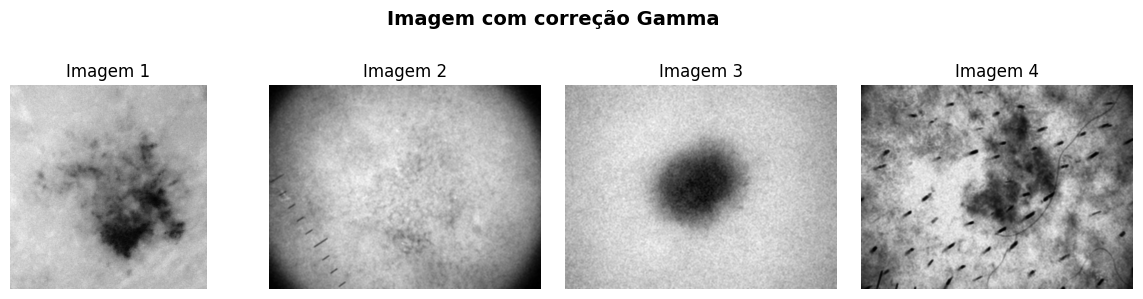

In [ ]:
show_grid(imgs_proc, title="Imagem com correção Gamma")

Aplicando Sharpening

In [ ]:
def unsharp_highboost(img, kernel_blur, k=1.0):
    blurred = np.clip(conv2d(img, kernel_blur), 0, 255).astype(np.uint8)
    mask = img.astype(np.float64) - blurred.astype(np.float64)
    sharpened = img.astype(np.float64) + k * mask
    return np.clip(sharpened, 0, 255).astype(np.uint8)

In [ ]:
imgs_hb_3 = [unsharp_highboost(img, mean_kernel(3), k=1.0) for img in imgs_proc]
imgs_hb_5 = [unsharp_highboost(img, mean_kernel(5), k=1.0) for img in imgs_proc]
imgs_hb_7 = [unsharp_highboost(img, mean_kernel(7), k=1.0) for img in imgs_proc]

In [ ]:
etapas_hb_kernel = {
    'Highboost kernel 3x3': imgs_hb_3,
    'Highboost kernel 5x5': imgs_hb_5,
    'Highboost kernel 7x7': imgs_hb_7
}

resultados_hb_kernel = []
for nome, imgs_k in etapas_hb_kernel.items():
    for i, (ref, img) in enumerate(zip(imgs_gray_p, imgs_k), start=1):
        resultados_hb_kernel.append({
            'Imagem': i, 'Kernel': nome,
            'PSNR': round(psnr(ref, img), 2),
            'SSIM': round(ssim_fn(ref, img), 4),
        })

df_kernel = pd.DataFrame(resultados_hb_kernel)
df_kernel

,Imagem,Kernel,PSNR,SSIM
0,1,Highboost kernel 3x3,26.41,0.7868
1,2,Highboost kernel 3x3,17.32,0.6998
2,3,Highboost kernel 3x3,21.83,0.7626
3,4,Highboost kernel 3x3,10.09,0.4879
4,1,Highboost kernel 5x5,26.27,0.7491
5,2,Highboost kernel 5x5,17.29,0.6624
6,3,Highboost kernel 5x5,21.78,0.7215
7,4,Highboost kernel 5x5,10.08,0.4500
8,1,Highboost kernel 7x7,26.15,0.7241
9,2,Highboost kernel 7x7,17.27,0.6386


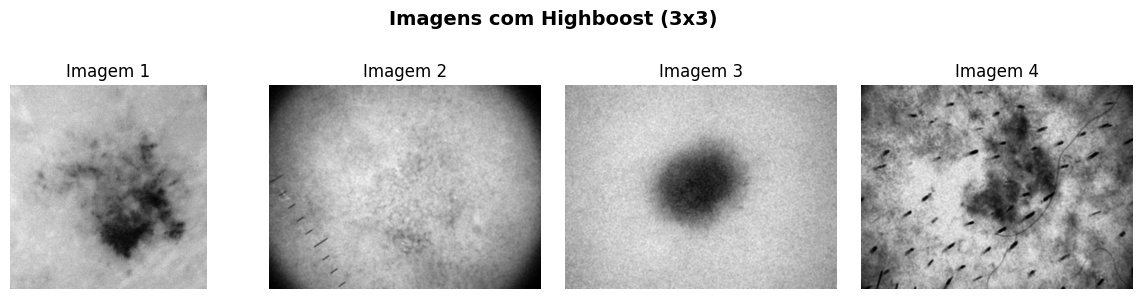

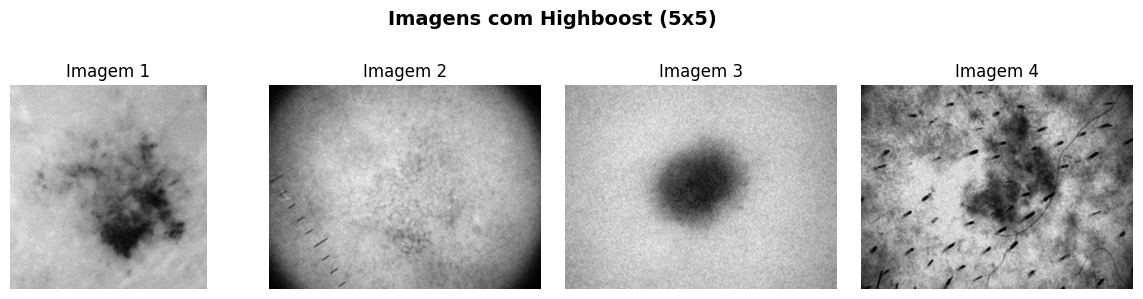

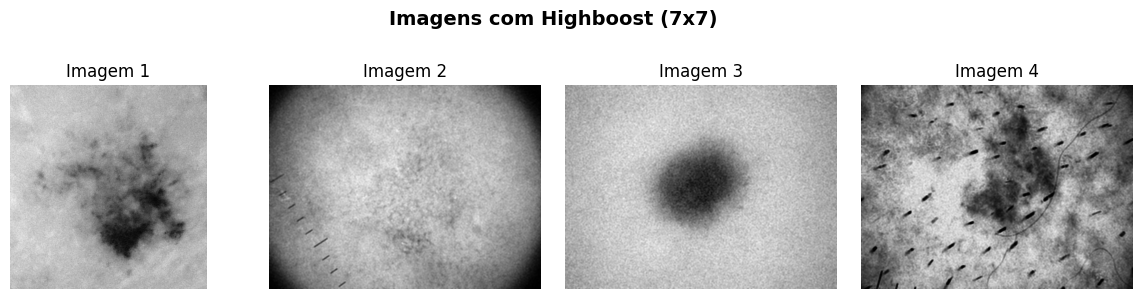

In [ ]:
show_grid(imgs_hb_3, title="Imagens com Highboost (3x3)")
show_grid(imgs_hb_5, title="Imagens com Highboost (5x5)")
show_grid(imgs_hb_7, title="Imagens com Highboost (7x7)")

In [ ]:
imgs_hb = imgs_hb_3

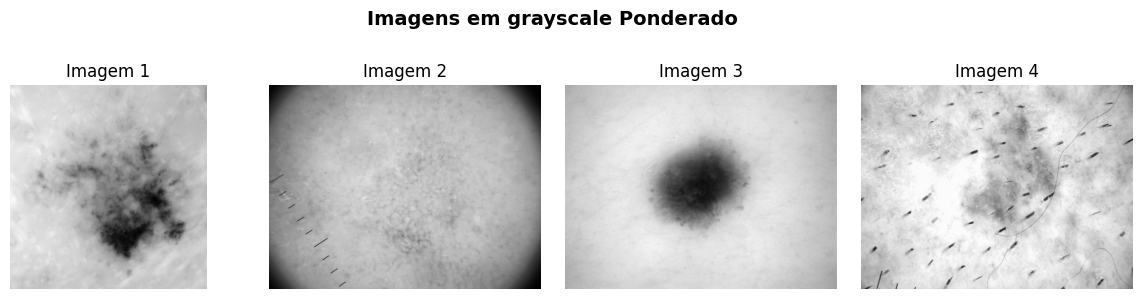

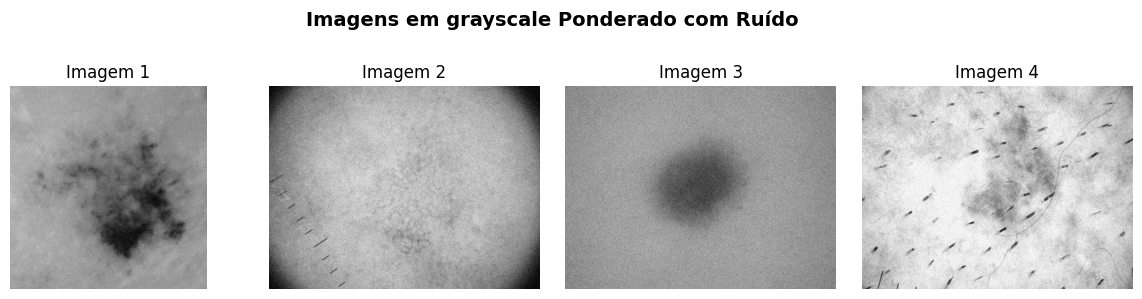

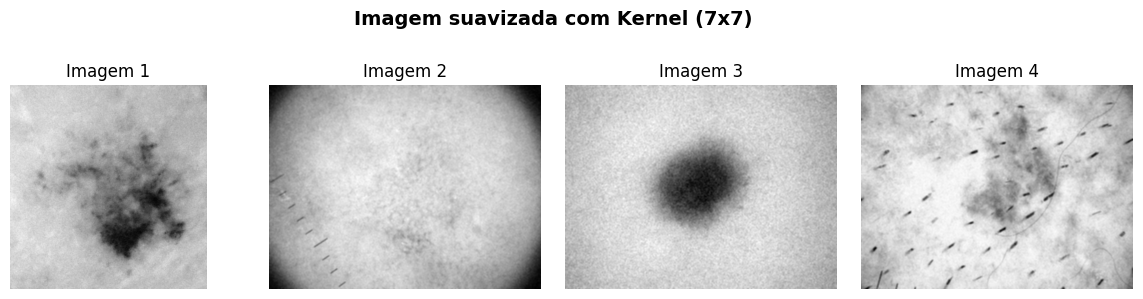

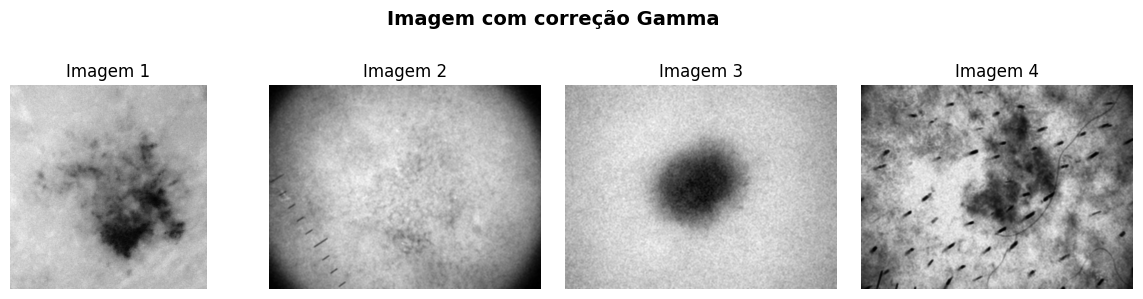

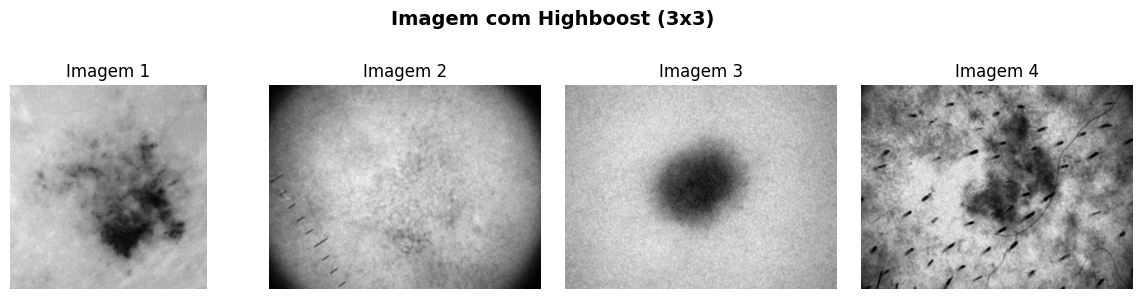

In [ ]:
show_grid(imgs_gray_p, title="Imagens em grayscale Ponderado")
show_grid(imgs_gray_p_noise, title="Imagens em grayscale Ponderado com Ruído")
show_grid(imgs_filtrados_7, title="Imagem suavizada com Kernel (7x7)")
show_grid(imgs_proc, title="Imagem com correção Gamma")
show_grid(imgs_hb, title="Imagem com Highboost (3x3)")

Aplicando métricas de qualidade

In [ ]:
etapas = {
    'Com Ruído':                            imgs_gray_p_noise,
    'Filtrada (Suavização 7x7)':            imgs_filtrados_7,
    'Processada (Gamma)':                   imgs_proc,
    "Final (Highboost kernel 3x3)":         imgs_hb
}

resultados = []
for nome_etapa, imgs_etapa in etapas.items():
    for i, (ref, img) in enumerate(zip(imgs_gray_p, imgs_etapa), start=1):
        resultados.append({
            'Imagem': i,
            'Etapa': nome_etapa,
            'PSNR (dB)': round(psnr(ref, img), 2),
            'SSIM': round(ssim_fn(ref, img), 4),
        })

df_metricas = pd.DataFrame(resultados)
df_metricas

,Imagem,Etapa,PSNR (dB),SSIM
0,1,Com Ruído,20.03,0.0983
1,2,Com Ruído,20.05,0.1155
2,3,Com Ruído,20.00,0.0908
3,4,Com Ruído,20.68,0.1996
4,1,Filtrada (Suavização 7x7),35.99,0.8733
5,2,Filtrada (Suavização 7x7),34.05,0.8467
6,3,Filtrada (Suavização 7x7),36.08,0.8724
7,4,Filtrada (Suavização 7x7),29.55,0.7960
8,1,Processada (Gamma),26.32,0.8604
9,2,Processada (Gamma),17.24,0.7766


# Segundo ciclo

Foi identificado que o resultado da imagem 4 estava sendo prejudicado em comparação as outras 3 imagens, onde é notável que após a correção gamma seus valores de PSNR e SSIM decaem drasticamente, então o foi identificado que o cálculo do gamma está fazendo que o gamma da imagem 4 fique muito alto, devido a ser mais claro em comparação as outras imagens. Por isso foi identificado que deveria ser limitado o valor do gamma, para que os valores fiquem mais estáveis, assim não tendo uma correção desproporcional.

In [ ]:
def auto_gamma_limitado(img, target_mean=0.5, gamma_min=0.5, gamma_max=2.0):
    mean_norm = np.mean(img) / 255.0
    if mean_norm <= 0:
        return 1.0
    gamma = np.log(target_mean) / np.log(mean_norm)
    return np.clip(gamma, gamma_min, gamma_max)

In [ ]:
gammas_limitados = [auto_gamma_limitado(img) for img in imgs_filtrados_7]
print(gammas_limitados)

imgs_proc_v2 = [gamma_correction(img, gamma=g) for img, g in zip(imgs_filtrados_7, gammas_limitados)]

for i, (ref, img_p) in enumerate(zip(imgs_gray_p, imgs_proc_v2), start=1):
    print(f"Imagem {i}: PSNR={psnr(ref, img_p):.2f}, SSIM={ssim_fn(ref, img_p):.4f}")

[np.float64(1.1334134953340442), np.float64(1.5547781079303917), np.float64(1.2557279643860797), np.float64(2.0)]
Imagem 1: PSNR=26.32, SSIM=0.8604
Imagem 2: PSNR=17.24, SSIM=0.7766
Imagem 3: PSNR=21.72, SSIM=0.8442
Imagem 4: PSNR=15.82, SSIM=0.7174


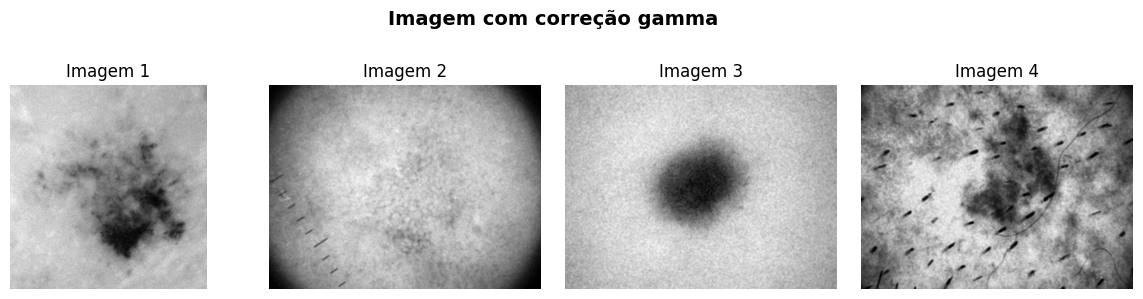

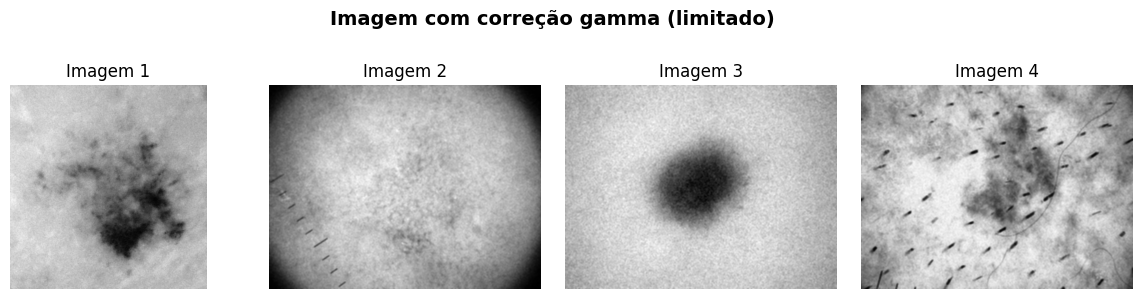

In [ ]:
show_grid(imgs_proc, title="Imagem com correção gamma")
show_grid(imgs_proc_v2, title="Imagem com correção gamma (limitado)")

In [ ]:
imgs_hb_v2 = [unsharp_highboost(img, mean_kernel(3), k=1.0) for img in imgs_proc_v2]

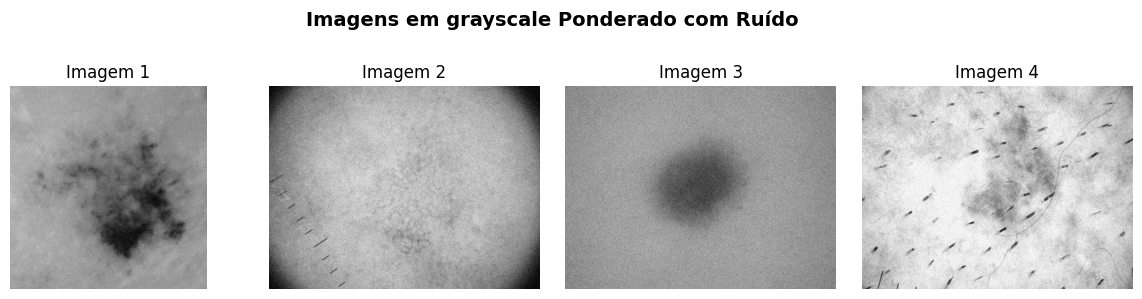

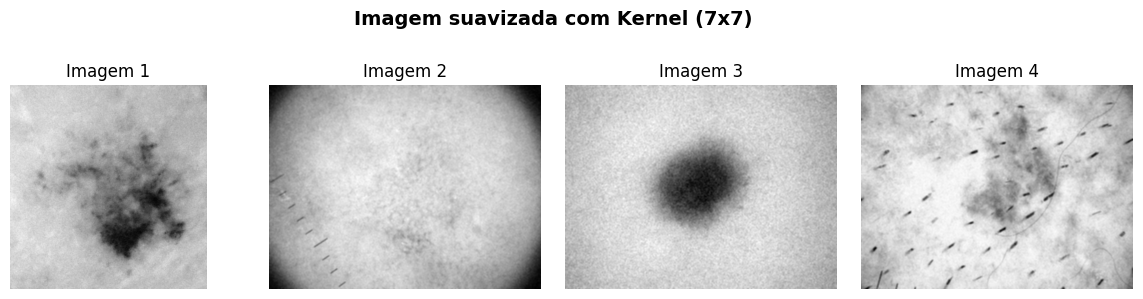

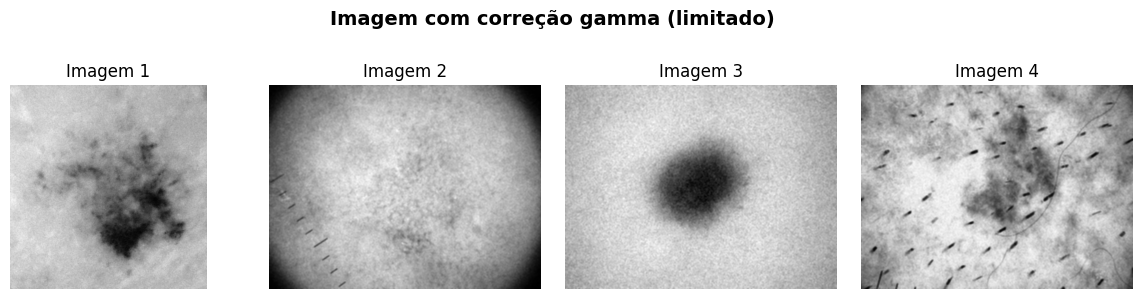

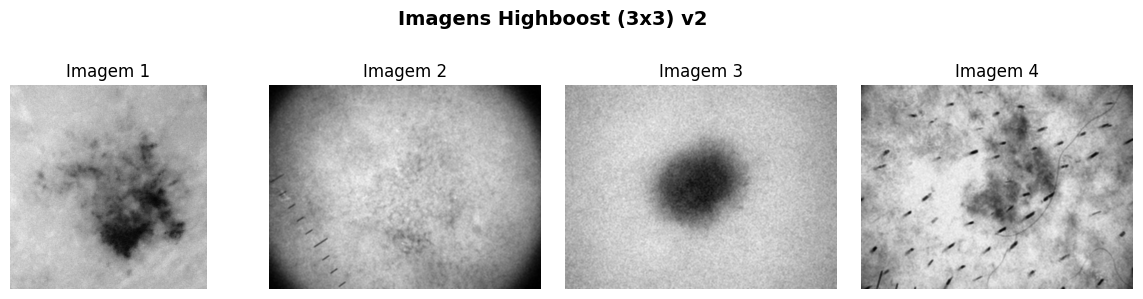

In [ ]:
show_grid(imgs_gray_p_noise, title="Imagens em grayscale Ponderado com Ruído")
show_grid(imgs_filtrados_7, title="Imagem suavizada com Kernel (7x7)")
show_grid(imgs_proc_v2, title="Imagem com correção gamma (limitado)")
show_grid(imgs_hb_v2, title="Imagens Highboost (3x3) v2")

In [ ]:
etapas_v2 = {
    'Com Ruído':                          imgs_gray_p_noise,
    'Filtrada (Suavização)':              imgs_filtrados_7,
    'Correção gamma (limitado)':          imgs_proc_v2,
    'Final (Highboost kernel 3x3 v2)':    imgs_hb_v2,
}

resultados_v2 = []
for nome_etapa, imgs_etapa in etapas_v2.items():
    for i, (ref, img) in enumerate(zip(imgs_gray_p, imgs_etapa), start=1):
        resultados_v2.append({
            'Imagem': i,
            'Etapa': nome_etapa,
            'PSNR (dB)': round(psnr(ref, img), 2),
            'SSIM': round(ssim_fn(ref, img), 4),
        })

df_metricas_v2 = pd.DataFrame(resultados_v2)
df_metricas_v2

,Imagem,Etapa,PSNR (dB),SSIM
0,1,Com Ruído,20.03,0.0983
1,2,Com Ruído,20.05,0.1155
2,3,Com Ruído,20.00,0.0908
3,4,Com Ruído,20.68,0.1996
4,1,Filtrada (Suavização),35.99,0.8733
5,2,Filtrada (Suavização),34.05,0.8467
6,3,Filtrada (Suavização),36.08,0.8724
7,4,Filtrada (Suavização),29.55,0.7960
8,1,Correção gamma (limitado),26.32,0.8604
9,2,Correção gamma (limitado),17.24,0.7766


In [ ]:
final_v1 = df_metricas[df_metricas['Etapa'] == 'Final (Highboost kernel 3x3)'].copy()

final_v1['Etapa'] = final_v1['Etapa'].replace({'Final (Highboost kernel 3x3)': 'Config 1'})

df_v1 = final_v1.pivot(
    index='Imagem',
    columns='Etapa',
    values=['PSNR (dB)', 'SSIM']
)
final_v2 = df_metricas_v2[df_metricas_v2['Etapa'] == 'Final (Highboost kernel 3x3 v2)'].copy()
final_v2['Etapa'] = final_v2['Etapa'].replace({'Final (Highboost kernel 3x3 v2)': 'Config 2'})

df_v2 = final_v2.pivot(
    index='Imagem',
    columns='Etapa',
    values=['PSNR (dB)', 'SSIM']
)

df_final = pd.merge(df_v1, df_v2, left_index=True, right_index=True, how='outer')
print(df_final)

       PSNR (dB)     SSIM PSNR (dB)     SSIM
Etapa   Config 1 Config 1  Config 2 Config 2
Imagem                                      
1          26.41   0.7868     26.41   0.7868
2          17.32   0.6998     17.32   0.6998
3          21.83   0.7626     21.83   0.7626
4          10.09   0.4879     15.87   0.6395


In [ ]:
dados = []

for i, img in enumerate(imgs_gray_p, start=1):

    global_std = np.std(img)

    borda = np.concatenate([
        img[:10, :].flatten(),
        img[-10:, :].flatten(),
        img[:, :10].flatten(),
        img[:, -10:].flatten()
    ])

    media_borda = np.mean(borda)
    media_total = np.mean(img)

    dados.append({
        "Imagem": i,
        "Desvio-padrão global": global_std,
        "Média da imagem": media_total,
        "Média da borda (10px)": media_borda,
        "Diferença (borda - média)": media_borda - media_total
    })

df_borda = pd.DataFrame(dados).round(2)
df_borda

,Imagem,Desvio-padrão global,Média da imagem,Média da borda (10px),Diferença (borda - média)
0,1,34.32,139.26,158.12,18.86
1,2,37.11,164.23,104.24,-59.98
2,3,18.77,147.84,145.48,-2.36
3,4,28.02,210.92,191.17,-19.75
